# Simulated Distribution Shift
This notebook goes through the process of simulating a distribution shift for the sklearn breast cancer diagnostic dataset. The following process is followed:
1. Analyze the key features of the benign and malignant data
2. Perform covariate shift: keep the percentage of benign and malignant samples the same as regular training, but shift the input features.
3. Perform feature perturbation: add gaussian noise to random samples within the dataset, 

In [217]:
import sys
import os

sys.path.append(os.path.abspath("../"))

import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()
X, y = data.data, data.target

malignant_inds = np.where(y == 0)[0]
benign_inds = np.where(y == 1)[0]
malignant_features = X[malignant_inds]
benign_features = X[benign_inds]

## 1. Feature analysis
The original paper found that when using their model, the mean texture, worst area, worst concavity, and worst fractal distance were the features which led to the best accuracy. It also stated that the extreme (worst) values are intuitvely more useful, since there may be only a few malignant cells within a tumor. So, we analyze these relationships to best create both realistic and disruptive dataset shifts.

### Texture

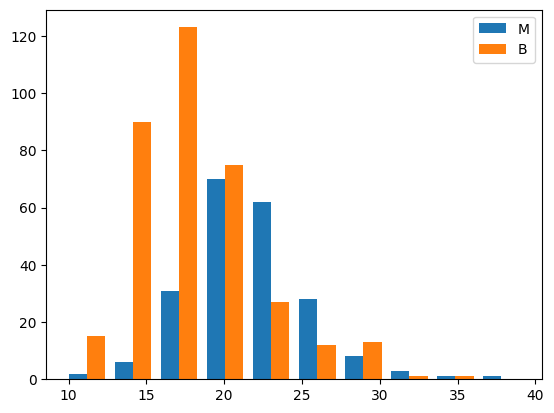

Malignant Mean Texture: 21.60490566037736
Malignant STD of Texture: 3.7705455401500347
Benign Mean Texture: 17.914761904761903
Benign STD of Texture: 3.9895252572260462


In [218]:
m_textures = malignant_features[:, 1]
b_textures = benign_features[:, 1]

plt.figure()
plt.hist([m_textures, b_textures], label=['M', 'B'])
plt.legend()

plt.show()

avg_m_textures = np.mean(m_textures)
std_m_textures = np.std(m_textures)
avg_b_textures = np.mean(b_textures)
std_b_textures = np.std(b_textures)

print('Malignant Mean Texture:', avg_m_textures)
print('Malignant STD of Texture:', std_m_textures)
print('Benign Mean Texture:', avg_b_textures)
print('Benign STD of Texture:', std_b_textures)


### Mean area vs. worst area

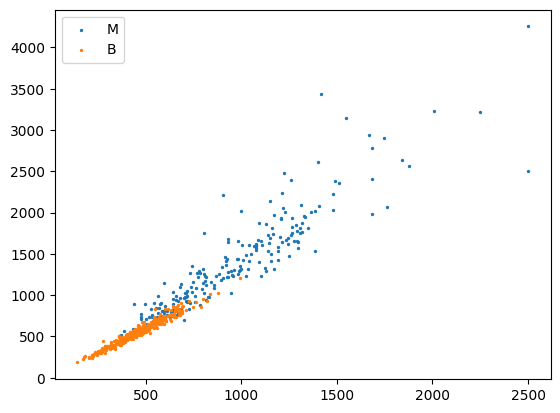

Malignant Worst Area Mean: 1422.2863207547173
Benign Worst Area Mean: 558.8994397759103


In [219]:
m_worst_area = malignant_features[:, 23]
m_mean_area = malignant_features[:, 3]
b_worst_area = benign_features[:, 23]
b_mean_area = benign_features[:, 3]

plt.figure()
plt.scatter(m_mean_area, m_worst_area, label='M', s=2)
plt.scatter(b_mean_area, b_worst_area, label='B', s=2)
plt.legend()
plt.show()

avg_m_worst_area= np.mean(m_worst_area)
avg_b_worst_area= np.mean(b_worst_area)

print('Malignant Worst Area Mean:', avg_m_worst_area)
print('Benign Worst Area Mean:', avg_b_worst_area)


### Mean concavity vs. worst concavity

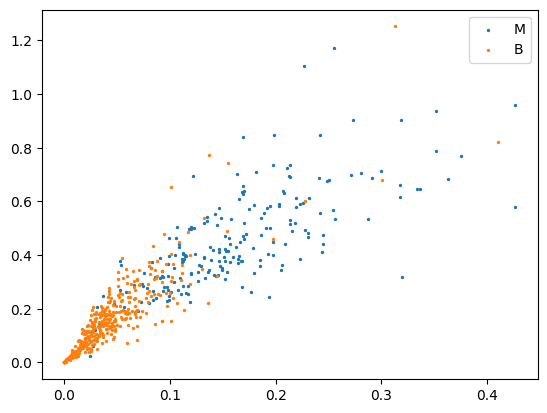

Malignant Worst Concavity Mean: 0.4506055660377358
Benign Worst Concavity Mean: 0.16623772268907563


In [220]:
m_worst_concavity = malignant_features[:, 26]
m_mean_concavity = malignant_features[:, 6]
b_worst_concavity = benign_features[:, 26]
b_mean_concavity = benign_features[:, 6]

plt.figure()
plt.scatter(m_mean_concavity, m_worst_concavity, label='M', s=2)
plt.scatter(b_mean_concavity, b_worst_concavity, label='B', s=2)
plt.legend()
plt.show()

avg_m_worst_concavity= np.mean(m_worst_concavity)
avg_b_worst_concavity= np.mean(b_worst_concavity)

print('Malignant Worst Concavity Mean:', avg_m_worst_concavity)
print('Benign Worst Concavity Mean:', avg_b_worst_concavity)

### Mean fractal distance vs. worst fractal distance

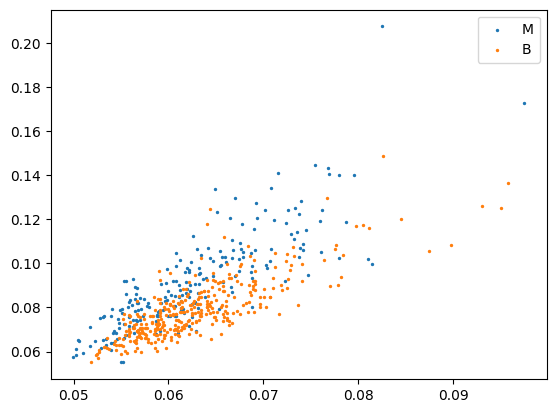

Malignant Worst FD Mean: 0.09152995283018868
Benign Worst FD Mean: 0.07944207282913165


In [221]:
m_worst_fd = malignant_features[:, 29]
m_mean_fd = malignant_features[:, 9]
b_worst_fd = benign_features[:, 29]
b_mean_fd = benign_features[:, 9]

plt.figure()
plt.scatter(m_mean_fd, m_worst_fd, label='M', s=2)
plt.scatter(b_mean_fd, b_worst_fd, label='B', s=2)
plt.legend()
plt.show()

avg_m_worst_fd= np.mean(m_worst_fd)
avg_b_worst_fd= np.mean(b_worst_fd)

print('Malignant Worst FD Mean:', avg_m_worst_fd)
print('Benign Worst FD Mean:', avg_b_worst_fd)

## 2. Covariate shift
From the analysis above, we can identify a few realistic types of covariate shift:
1. Different hospitals may have different stains and human error can also lead to poorer staining of the cells, so texture (the standard deviation of gray-scale values) could vary based on the equipment used.
2. Different hospitals may use different segmentation algorithms, so the features of concavity, area, and fractal distance could vary based on equipment used as well.

Create a dataset which decreases the texture values, simulating lower contrast/staining quality. This would not affect benign cells, since they are already fairly uniform. So, only malignant samples experience this shift. Also increase area, decrease concavity, and decrease fractal distance to represent a less effective segmentation algorithm. Again, healthy cells should already be very round and smaller in area, so this issue only affects the malignant classes. 

In [222]:
def perform_shift(shifted_ds, og_ds, feature_ind, class_inds, inc, sf, print_values=False, feature_name=None):
    feature_data = og_ds[class_inds, feature_ind]
    std_og = np.std(feature_data)
    random_texture = np.random.normal(std_og/sf, std_og/(sf*2), feature_data.shape)

    if not inc:
        random_texture = random_texture * -1
    shifted_ds[malignant_inds, feature_ind] = feature_data + random_texture


    if print_values:
        max_og = np.max(feature_data)
        min_og = np.min(feature_data)

        new_min = np.min(shifted_ds[class_inds, feature_ind])
        new_max = np.max(shifted_ds[class_inds, feature_ind])
        new_std = np.std(shifted_ds[class_inds, feature_ind])

        print(f'Original Min {feature_name}: {min_og}\nShifted Min {feature_name}: {new_min}\n')
        print(f'Original Max {feature_name}: {max_og}\nShifted Max {feature_name}: {new_max}\n')
        print(f'Original STD {feature_name}: {std_og}\nShifted STD {feature_name}: {new_std}\n')

In [ ]:
covar_shift_dataset = np.array([row for row in X])

# randomly decrease malignant textures
perform_shift(covar_shift_dataset, X, 1, malignant_inds, False, 2, print_values=True, feature_name='Texture Mean')

# randomly increase worst malignant areas
perform_shift(covar_shift_dataset, X, 23, malignant_inds, True, 12, print_values=True, feature_name='Worst Area')

# randomly decrease worst malignant convexity
perform_shift(covar_shift_dataset, X, 26, malignant_inds, False, 8, print_values=True, feature_name='Worst Convexity')

# randomly decrease worst fractal distance
perform_shift(covar_shift_dataset, X, 29, malignant_inds, False, 6, print_values=True, feature_name='Worst Fractal Distance')

Original Min Texture Mean: 10.38
Shifted Min Texture Mean: 7.897436753429187

Original Max Texture Mean: 39.28
Shifted Max Texture Mean: 37.70334085043128

Original STD Texture Mean: 3.7705455401500347
Shifted STD Texture Mean: 4.031571004970954

Original Min Worst Area: 361.6
Shifted Min Worst Area: 383.47867277530975

Original Max Worst Area: 2501.0
Shifted Max Worst Area: 2535.1392966599474

Original STD Worst Area: 367.0691736135536
Shifted STD Worst Area: 366.1641664321593

Original Min Worst Convexity: 0.02398
Shifted Min Worst Convexity: 0.015144694933845142

Original Max Worst Convexity: 0.4268
Shifted Max Worst Convexity: 0.42703650524411085

Original STD Worst Convexity: 0.074842186333034
Shifted STD Worst Convexity: 0.07507215047229693

Original Min Worst Fractal Distance: 0.04996
Shifted Min Worst Fractal Distance: 0.04852225151515723

Original Max Worst Fractal Distance: 0.09744
Shifted Max Worst Fractal Distance: 0.0971415659296871

Original STD Worst Fractal Distance: 0.

## 3. Feature Perturbation
Add random noise to the metrics. To do this, first randomly select features to add noise to for each sample. Add a small amount of random noise to each of these features.

In [261]:
def perform_noise_injection(shifted_ds, og_ds, feature_inds, sample, print_values=False, feature_name=None):
    feature_data = og_ds[sample, feature_inds]
    std_og = np.std(og_ds[:, feature_inds], axis=0)
    random_texture = np.random.normal(0, std_og/2, feature_data.shape)

    shifted_ds[sample, feature_inds] = np.abs(feature_data + random_texture)


    if print_values:
        max_og = np.max(feature_data)
        min_og = np.min(feature_data)

        new_min = np.min(shifted_ds[sample, feature_inds])
        new_max = np.max(shifted_ds[sample, feature_inds])
        new_std = np.std(shifted_ds[sample, feature_inds])

        print(f'Original Min {feature_name}: {min_og}\nShifted Min {feature_name}: {new_min}\n')
        print(f'Original Max {feature_name}: {max_og}\nShifted Max {feature_name}: {new_max}\n')
        print(f'Original STD {feature_name}: {std_og}\nShifted STD {feature_name}: {new_std}\n')

In [270]:
feature_noise_dataset = np.array([row for row in X])

for i in range(feature_noise_dataset.shape[0]):
    features = np.random.choice(np.arange(30), 10)
    perform_noise_injection(feature_noise_dataset, X, features, i)


max_og = np.max(X[:, 1])
min_og = np.min(X[:, 1])
std_og = np.std(X[:, 1])

new_min = np.min(feature_noise_dataset[:, 1])
new_max = np.max(feature_noise_dataset[:, 1])
new_std = np.std(feature_noise_dataset[:, 1])
feature_name = "Texture"
print(f'Original Min {feature_name}: {min_og}\nShifted Min {feature_name}: {new_min}\n')
print(f'Original Max {feature_name}: {max_og}\nShifted Max {feature_name}: {new_max}\n')
print(f'Original STD {feature_name}: {std_og}\nShifted STD {feature_name}: {new_std}\n')

Original Min Texture: 9.71
Shifted Min Texture: 7.930771482918258

Original Max Texture: 39.28
Shifted Max Texture: 39.28

Original STD Texture: 4.297254637090421
Shifted STD Texture: 4.493666397321492

